In [1]:
import os
import sys
sys.path.append(os.path.expanduser("~"))
from camel_dataloader import get_astro_data,get_astro_data_2D_from_3D, Rescale
from utils import draw_figure,compute_pk, plot_residual, test_plot, InverseCosineLR
sys.path.append('/pscratch/sd/l/lindajin/ICdiffusion/')
from model import BigGANUNet2DModel
import comet_ml
import torch
from torch import nn
from torch.nn.functional import mse_loss, l1_loss
from torch import autograd, Tensor
from lightning.pytorch import LightningModule, Trainer, seed_everything
from lightning.pytorch.loggers import CometLogger
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from typing import Optional, Tuple
from torch.special import expm1
from tqdm import trange
from torch.distributions.normal import Normal
import numpy as np
import matplotlib.pyplot as plt

torch.set_float32_matmul_precision('highest')
device = torch.device("cuda") if torch.cuda.is_available() else "mps"
print(device)

cuda


In [2]:
seed_everything(42, workers=True)
cropsize = 256
batch_size = 4 #12
num_workers = 8
   
dataset = 'Astrid'
learning_rate = 1e-3 #1e-4


[rank: 0] Seed set to 42


In [8]:
class trainCNN(LightningModule):
    def __init__(
        self,
        model,
        learning_rate: float = 3.0e-3,
        weight_decay: float = 1.0e-2,
        fourier_upweight_range=(6, 20), 
        fourier_weight=1e-5,
        fourier_loss_scheduler=True,
        draw_figure=None,
        test_plot=None,
        dataset='illustris',
        model_type = 'TF', #'UNet' for residual prediction, 'ResNet' for Mtot
        rescale = True,
        **kwargs
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["draw_figure","plot_residual"])
        
        self.model= model
        self.dataset=dataset
        print("suite:", self.dataset)
        self.draw_figure=draw_figure
        self.test_plot=test_plot
        self.fourier_upweight_range = fourier_upweight_range
        self.fourier_weight = fourier_weight
        self.fourier_loss_scheduler = fourier_loss_scheduler
        self.model_type = model_type
        self.rescale = rescale
        
        if self.draw_figure is None:
            def draw_figure(args,**kwargs):
                fig=plt.figure(figsize=(5,5))
                return fig
            self.draw_figure=draw_figure

    def forward(self, cdm_map, params) -> Tensor:
        cdm_map = cdm_map
        params = params
        output = self.model(cdm_map, params) #output kernel should give the invertible Fourier transformation
        return output

    def evaluate(self, batch: Tuple, stage: str = None) -> Tensor:

        cdm_map,params,true_map = batch
        cdm_map = cdm_map.to(device)
        params = params.to(device)
        true_map = true_map.to(device)
        mtot_pred = self(cdm_map,params).to(device)
        fourier_loss = self.fourier_loss(mtot_pred, true_map)
        # Log the individual loss components
        self.log("fourier_loss", fourier_loss, on_epoch=True, prog_bar=True)
        loss = l1_loss(mtot_pred[:,0,:,:].unsqueeze(1), true_map)
        self.log("l1_loss", loss, on_epoch=True, prog_bar=True)
        rcc_loss = self.rcc_loss(mtot_pred[:,0,:,:].unsqueeze(1), true_map)
        self.log("rcc_loss", rcc_loss, on_epoch=True, prog_bar=True)
        #EFT_loss = self.EFT_ch_loss(mtot_pred, true_map)
        #self.log("EFT_loss", EFT_loss, on_epoch=True, prog_bar=True)
        return loss #+ 10*rcc_loss

    def weighted_l1_loss(self, batch: Tuple, stage: str = None) -> Tensor:

        cdm_map,params,true_map = batch
        cdm_map = cdm_map.to(device)
        params = params.to(device)
        true_map = true_map.to(device)
        mtot_pred = self(cdm_map,params).to(device)

        return l1_loss(mtot_pred, true_map)

    def get_current_min_max_freq(self):
        if self.trainer is None:
            return self.fourier_upweight_range[0], self.fourier_upweight_range[1]
            
        progress = self.current_epoch / self.trainer.max_epochs
        min_freq = self.fourier_upweight_range[0]
        max_freq = self.fourier_upweight_range[1]
    
        if progress < 0.1:
            return 0.0, 2
        elif progress < 0.3:
            return min_freq / 2, min_freq / 2 + 4
        elif progress < 0.6:
            return min_freq * 3/ 4, min_freq * 3/ 4 + 8
        else:
            return min_freq, max_freq
            
    def EFT_ch_loss(self, output, target):
        '''
        output: [N,2,p,p]
        '''
        if self.model_type != 'EFT':
            return 0    
        target_fft = torch.fft.fft2(target)
        output_fft = torch.fft.fft2(output[:,0,:,:].unsqueeze(1))
        
        _, C, H, W = target.shape
        L = 25. #Mpc/c
        kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L)).to(target.device)
        ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L)).to(target.device)
        kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
        k = torch.sqrt(kx**2 + ky**2) 

        
        cross_correlation_fft = target_fft * torch.conj(output_fft)
        # Inverse FFT to get spatial cross-correlation
        cross_correlation = torch.fft.ifft2(cross_correlation_fft).real
        # Normalize cross-correlation coefficient
        norm1 = torch.sqrt(torch.sum(target_fft**2))
        norm2 = torch.sqrt(torch.sum(output_fft**2))
        rcc = cross_correlation / (norm1 * norm2)

        a = torch.randn(1,device = target.device)
        term_c = torch.fft.ifft2(output_fft * a * k**2)
        term_J = torch.fft.ifft2(target_fft * (1-rcc**2)**0.5)

        return l1_loss(output[:,1,:,:].unsqueeze(1),  term_c.real+term_J.real)


    def rcc_loss(self, output, target):
        if self.rescale:
            output, target = Rescale(constant=0.5,power=0.2).inverse_transform([output, target])
        k, P = compute_pk(target.cpu().detach().numpy(), output.cpu().detach().numpy())
        rcc = Tensor(P)
    
        self.log("rcc_train", rcc.real.mean(), on_epoch=True, prog_bar=True)
        
        return torch.mean((1-rcc.real)**2)
    
    def fourier_loss(self, output, target):
        ## Low pass only
        if self.fourier_loss_scheduler:
            low, high = self.get_current_min_max_freq() 
        else:
            high = self.fourier_upweight_range[1]
            low = self.fourier_upweight_range[0] 
        
        a = torch.randn(1,device = target.device) * self.fourier_weight
        
        output_filtered, output_filtered_eft  = self.fourier_filter_EFT(output[:,0,:,:].unsqueeze(1),low,high,a)
        target_filtered, target_filtered_eft = self.fourier_filter_EFT(target,low,high,a)
        # kcc, rcc = compute_pk(output_filtered_real.cpu().detach().numpy(),target_filtered_real.cpu().detach().numpy())
        # 100*torch.mean(1 - Tensor(rcc)**2)
        if self.model_type == 'EFT':
            output_filtered_eft = output[:,1,:,:].unsqueeze(1)
            
        loss = torch.mean((output_filtered - target_filtered) ** 2) + torch.mean((output_filtered_eft - target_filtered_eft) ** 2) #r_cc is phase not mag
        return loss

    def fourier_filter_EFT(self, target, low=3, high=7, a = -0.001 ):
        target_fft = torch.fft.fft2(target)

        _, C, H, W = target.shape
        L = 25. #Mpc/c
        kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L)).to(target.device)
        ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L)).to(target.device)
        kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
        k = torch.sqrt(kx**2 + ky**2) 

        order = 2 #2
        low_pass = 1 / (1 + (k / high)**(2 * order))
        high_pass = 1 / (1 + (low / k)**(2 * order))
    
        epsilon = 1e-10  # Small value to avoid division by zero
        if low == 0:
            weight_mask = low_pass / torch.clamp(sum(low_pass), min=epsilon) + 1e-3
        else:
            weight_mask = low_pass*high_pass / torch.clamp(sum(low_pass*high_pass), min=epsilon)  + 1e-3
    

        # Expand the mask for all batches and channels
        weight_mask = weight_mask[None, :, :].to(target.device)

        filtered_target = torch.fft.ifft2(weight_mask * target_fft)
        delta = torch.fft.fft2(filtered_target.real)

        cross_correlation_fft = target_fft * torch.conj(delta)
        # Inverse FFT to get spatial cross-correlation
        cross_correlation = torch.fft.ifft2(cross_correlation_fft).real
        # Normalize cross-correlation coefficient
        norm1 = torch.sqrt(torch.sum(target_fft**2))
        norm2 = torch.sqrt(torch.sum(delta**2))
        rcc = cross_correlation / (norm1 * norm2)

        term_c = torch.fft.ifft2(delta* a * k**2)
        term_J = torch.fft.ifft2(target_fft * (1-rcc**2)**0.5)
        
        return filtered_target.real + term_c.real + term_J.real, filtered_target.imag + term_c.imag + term_J.imag

    def rcc_mean(self,batch):
        cdm_map,params,true_map = batch
        cdm_map = cdm_map.to(device)
        params = params.to(device)
        if self.rescale:
            cdm_map, true_map = Rescale(constant=0.5,power=0.2).inverse_transform([cdm_map, true_map])
        if self.model_type == 'UNet':
            target_mtot = true_map.to(device) + cdm_map
            pred_mtot = self(cdm_map,params).to(device) + cdm_map
        else:
            target_mtot = true_map.to(device)[:,0,:,:].unsqueeze(1) 
            pred_mtot = self(cdm_map.to(device),params.to(device)).to(device)[:,0,:,:].unsqueeze(1) 
        kcc, P = compute_pk(target_mtot.cpu().detach().numpy(), pred_mtot.cpu().detach().numpy())
        return P.mean()
        

    def training_step(
        self,
        batch: Tuple,
        batch_idx: int,
    ) -> Tensor:
        loss = self.evaluate(batch, "train")
        self.log("train_loss", loss, on_epoch=True)
        log_loss = torch.log(loss)
        return log_loss


    def validation_step(self, batch: Tuple, batch_idx: int) -> Tensor:
        """validate model

        Args:
            batch (Tuple): batch of examples
            batch_idx (int): idx for batch

        Returns:
            Tensor: loss
        """
        conditioning,params,x = batch 
        loss = 0   
        
        if batch_idx == 0:
            sample = self(conditioning,params)
            loss = self.evaluate(batch)
            self.log("val_loss", loss, on_epoch=True, prog_bar=True)
            l1 = self.weighted_l1_loss(batch)
            #rcc = self.rcc_mean(batch)
            self.log("val_l1_loss", l1, on_epoch=True, prog_bar=True)
            #self.log("val_rcc", rcc, on_epoch=True, prog_bar=True)
            fig = self.draw_figure(x,sample,conditioning,self.dataset,model=self.model_type,Rescale=self.rescale)            
            if self.logger is not None:
                self.logger.experiment.log_figure(figure=fig)
          
            plt.close()
        return loss

    def test_step(self, batch, batch_idx):
        
        conditioning, params, x = batch    
        loss = 0    
        
        if batch_idx == 0:
            sample = self(conditioning,params)
            fig = self.draw_figure(x,sample,conditioning,self.dataset,model=self.model_type,Rescale=self.rescale)
            fig_test = self.test_plot(x,sample,conditioning,self.dataset,model=self.model_type,Rescale=self.rescale)
            self.log_dict({'test_loss': loss}, on_epoch=True)
            if self.logger is not None:
                self.logger.experiment.log_figure(figure=fig)
                self.logger.experiment.log_figure(figure=fig_test)

                loss = self.weighted_l1_loss(batch)
                self.logger.log_metrics({"test_l1_loss": loss.mean()})
                rcc = self.rcc_mean(batch)
                self.log("test_rcc", rcc, on_epoch=True, prog_bar=True)
            plt.show()
        return self.evaluate(batch, "test")
 
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=self.hparams.weight_decay,
        )
        warmup_steps = int(self.trainer.max_steps * 0.3)
        '''
        scheduler =torch.optim.lr_scheduler.LinearLR(
                    optimizer, 
                    start_factor=0.1, 
                    end_factor=1.0, 
                    total_iters=warmup_steps
                )
        '''
        if self.fourier_loss_scheduler:
            T_0 = self.trainer.max_epochs // 4
        else: 
            T_0=2
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[
                # Linear warmup
                
                torch.optim.lr_scheduler.LinearLR(
                    optimizer, 
                    start_factor=0.1, 
                    end_factor=1.0, 
                    total_iters=warmup_steps
                ),
                
                # Cosine Annealing with Warm Restarts
                #torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                #   optimizer, 
                #   T_0=T_0,           # Initial restart period
                #   T_mult=2,     # Multiplicative factor for restart periods
                #   eta_min=1e-6    # Minimum learning rate
                #),

                InverseCosineLR(
                optimizer,
                T_0=T_0,             # Initial restart period
                T_mult=2,            # Multiplicative factor for restart periods
                eta_min=self.hparams.learning_rate,  # Start with the base learning rate
                eta_max=self.hparams.learning_rate * 10  # Increase to 10x the base learning rate
            )

            ],
            milestones=[warmup_steps]
        )
        
        return {'optimizer': optimizer, 'lr_scheduler': scheduler}
    
    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        cdm_map,params,true_map = batch
        return self(cdm_map,params)

In [27]:
import importlib
import unet_parts
import unet_model
import camel_dataloader
import utils
import model

importlib.reload(camel_dataloader) 
from camel_dataloader import get_astro_data,get_astro_data_2D_from_3D

importlib.reload(utils) 
importlib.reload(unet_parts) 
importlib.reload(model) 
from utils import draw_figure,test_plot,InverseCosineLR
from model import BigGANUNet2DModel
importlib.reload(unet_model) 
from unet_model import UNetFiLM,UNetFiLMNoSkip

In [9]:
sys.path.append('/pscratch/sd/l/lindajin/Pytorch-UNet/unet')
from unet_model import UNetFiLM,ResNetFiLM,UNetFiLMNoSkip
cnn = trainCNN(
        model =BigGANUNet2DModel(1,1, bilinear = False, use_fourier_features = True, attention = True), #.to(device) #SimpleNet() #ResnetGenerator(1,1) #SimpleNet()
        dataset=dataset,
        learning_rate = 3.0e-5,
        image_shape=(1,cropsize,cropsize),
        fourier_weight=1e-2,
        draw_figure=draw_figure,
        test_plot=test_plot,
        fourier_loss_scheduler=True,
        model_type = 'ResNet',
    ).to(device)

    # Checkpoint every time val_loss improves
val_rcc_checkpoint = ModelCheckpoint(
        filename="best_rcc_model-{epoch}-{step}",
        monitor="val_rcc",
        save_top_k=1, # save only the best ckpt
        mode="max",
        verbose=True,        
    )

val_l1_checkpoint = ModelCheckpoint(
        filename="best_l1_model-{epoch}-{step}",
        monitor="val_l1_loss",
        save_top_k=1, # save only the best ckpt
        mode="min",
        verbose=True,        
    )
    # Checkpoint at every 6000 steps
latest_checkpoint = ModelCheckpoint(
        filename="latest-{epoch}-{step}",
        monitor="step",
        mode="max",
        every_n_train_steps=50, # 50 6000
        save_top_k=10
    )

comet_logger = CometLogger(
            api_key=os.environ.get("COMET_API_KEY"),
            project_name="astrid",
            experiment_name='BigGANUNet2DModel_lr_tuning_warmup0.3_increasing_lr_epoch20_L1_lr_3e5_adamw_1e2_25_thickness_Nbody_Rescale',
            offline=False,
            save_dir='/pscratch/sd/l/lindajin/LOGS/',
            experiment_key='f244764908c843a78275d1b5845a75b3'
)

trainer = Trainer(
        logger=comet_logger,
        accelerator="auto",
        max_epochs=20, #10 1000
        gradient_clip_val=0.5,
        callbacks=[LearningRateMonitor(),
                    latest_checkpoint,
                    #val_rcc_checkpoint,
                    val_l1_checkpoint
                  ],
        devices=[3]   
)

CometLogger will be initialized in online mode


suite: Astrid


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [18]:
print(cnn.device)

cuda:0


In [33]:
import importlib
import unet_model
import unet_parts
import utils
importlib.reload(utils) 
importlib.reload(unet_parts) 
from utils import power, draw_figure
from unet_model import UNetFiLM, FiLM, ResNetFiLM
from unet_parts import *

## Conditional ResNet: m_cdm -> m_tot (25 thickness)

In [3]:
dm_25_thick_mtot = get_astro_data(
        dataset,
        25,
        num_workers=num_workers,
        batch_size=batch_size,
    )

In [ ]:
trainer.fit(model=cnn, datamodule=dm_25_thick_mtot,ckpt_path=path_l1)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/astrid/f244764908c843a78275d1b5845a75b3

/global/u1/l/lindajin/virtualenvs/env1/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /pscratch/sd/l/lindajin/LOGS/astrid/f244764908c843a78275d1b5845a75b3/checkpoints exists and is not empty.
Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/astrid/f244764908c843a78275d1b5845a75b3/checkpoints/best_l1_model-epoch=1-step=1050.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | BigGANUNet2DModel | 27.2 M | train

CHNG: m_totking: |          | 0/? [00:00<?, ?it/s]
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_tot

CHNG: m_tot

CHNG: m_totCHNG: m_totCHNG: m_tot

CHNG: m_tot

CHNG: m_totCHNG: m_totCHNG: m_tot

CHNG: m_tot

CHNG: m_totCHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot


CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot

CHNG: m_tot


CHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot




CHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot


CHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_totCHNG: m_tot



CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 

In [7]:
#path_rcc = val_rcc_checkpoint.best_model_path 
#print('best Rcc model:'+path_rcc)
path_l1 = val_l1_checkpoint.best_model_path 
print('best L1 model:'+path_l1)

best L1 model:/pscratch/sd/l/lindajin/LOGS/astrid/f244764908c843a78275d1b5845a75b3/checkpoints/best_l1_model-epoch=1-step=1050.ckpt


In [ ]:
test_loss = trainer.test(model=cnn, datamodule=dm_25_thick_mtot, ckpt_path = path_l1)
#test_loss = trainer.test(model=cnn, datamodule=dm_25_thick_mtot, ckpt_path = path_rcc)

In [ ]:
comet_logger.experiment.end()

## Conditional CNN + Fourier Loss: m_cdm -> m_tot-m_cdm(Nbody) (3D->2D: 25 thickness)

In [4]:
dm_25_thick = get_astro_data(
        dataset,
        25,
        num_workers=num_workers,
        batch_size=batch_size,
    )

In [6]:
print(len(dm_25_thick.train_data), len(dm_25_thick.valid_data),len(dm_25_thick.test_data))

2100 600 300


In [11]:
trainer.fit(model=cnn, datamodule=dm_25_thick) 

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/nbody-hydro/62414b1a49d44937b8d266433aea8335

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : BigGANUNet2DModel_batch4_vali_rcc_lr_tuning_warmup_fourier_feature_6_7_epoch20_moving_highk_log_Fourier_L1_weight_5e3_10_Smooth_Butterworth_lr_3e4_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                

ValueError: Expected integer T_mult >= 1, but got 1.5

In [8]:
best_path = val_checkpoint.best_model_path 
print(best_path)

In [ ]:
last_path = trainer.checkpoint_callback.best_model_path 
print(last_path)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/nbody-hydro/1ea59249057b460098c94cd3723df212

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/Nbody_Hydro/1ea59249057b460098c94cd3723df212/checkpoints/best_model-epoch=18-step=9975.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'BigGANUNet2DModel(
  (fourier_features): FourierFeatures()
  (act): SiLU()
  (all_modules): ModuleList(
    (0): Conv2d(9, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1-2): 2 x ResnetBlockBigGANpp(
      (GroupNorm_0): GroupNorm(8, 32, eps=1e-06, affine=True)
      (Conv_

CHNG: m_totCHNG: m_totCHNG: m_tot?, ?it/s]


CHNG: m_totCHNG: m_totCHNG: m_tot


CHNG: m_totCHNG: m_tot

CHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot


CHNG: m_totCHNG: m_tot

CHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot

CHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_tot


CHNG: m_tot


CHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot

CHNG: m_totCHNG: m_tot


CHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot

CHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_tot




CHNG: m_totCHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot



CHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_tot

CHNG: m_totCHNG: m_tot



CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_tot




CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot



CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_tot
CHNG: m_tot


CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_totCHNG: m_t

/global/homes/l/lindajin/utils.py:343: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.flat[0].legend()
/global/homes/l/lindajin/utils.py:369: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.flat[2].legend()
/global/homes/l/lindajin/utils.py:380: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.flat[3].legend()


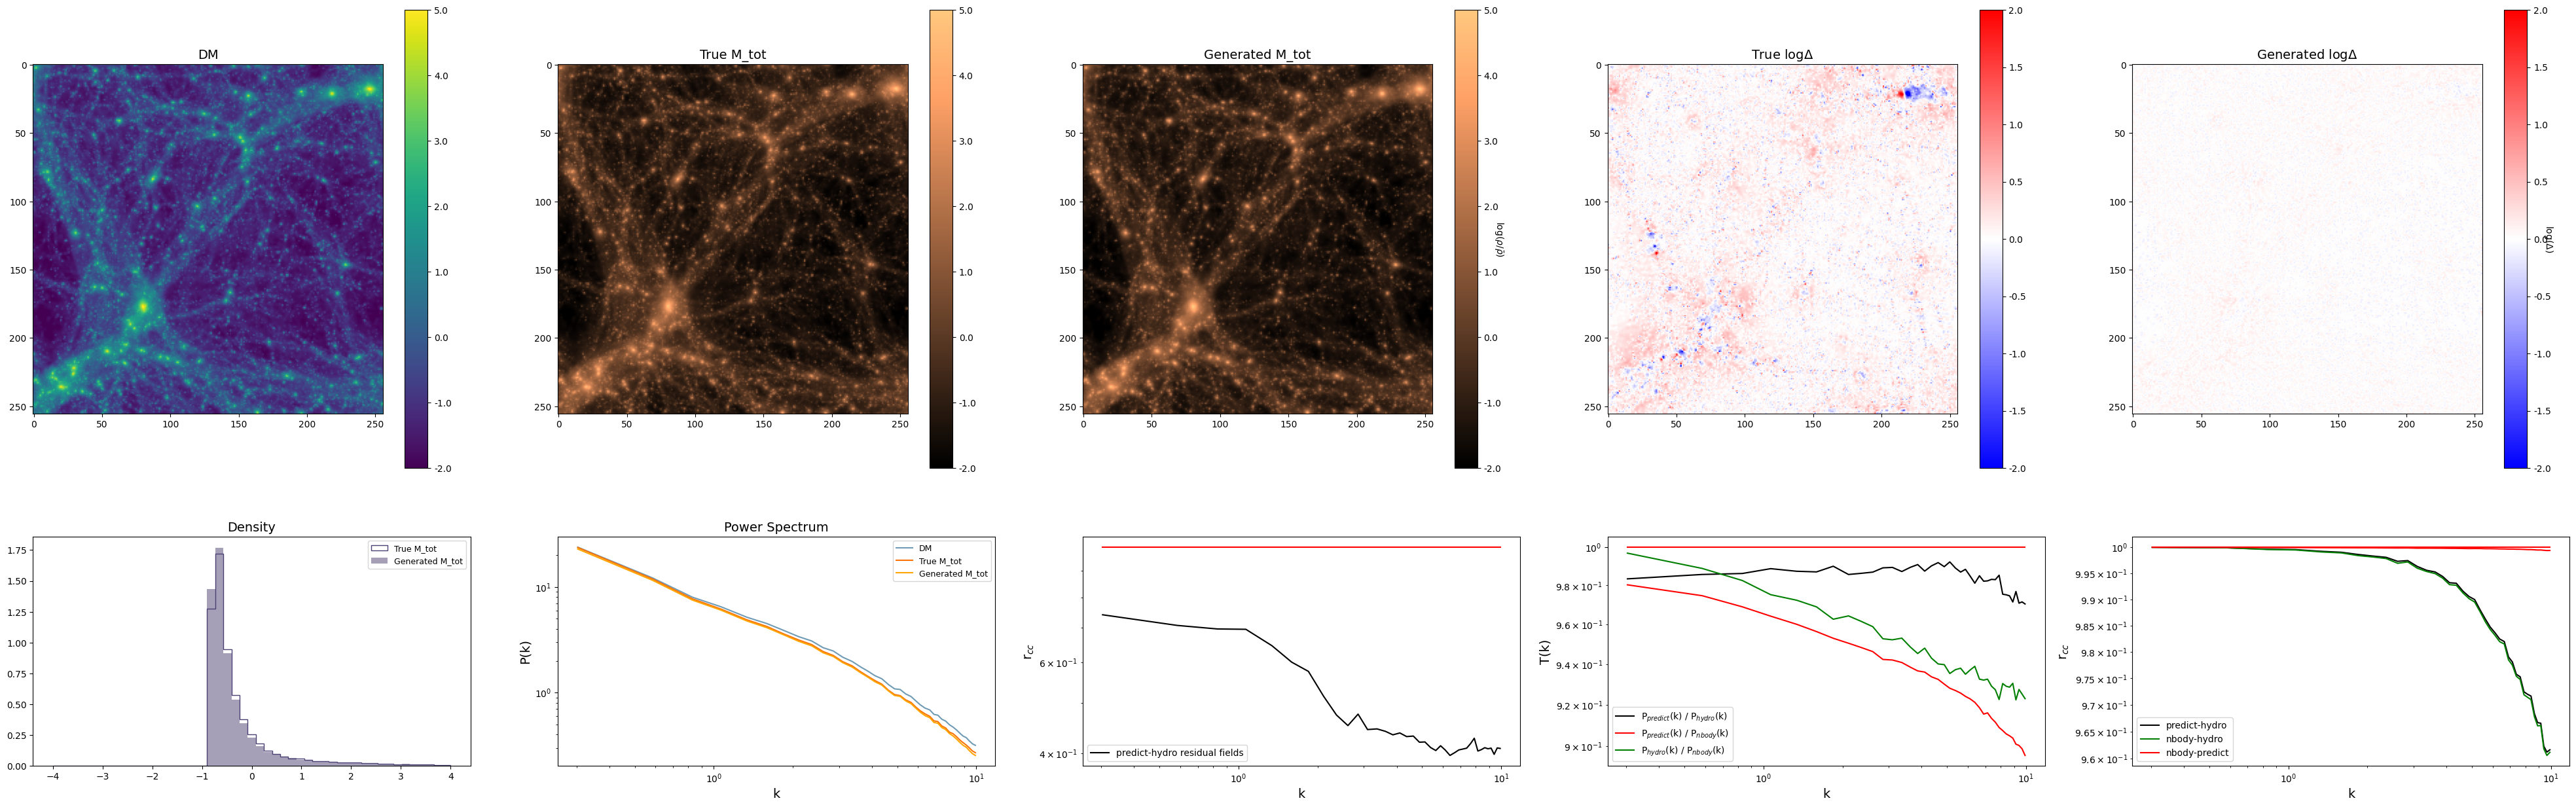

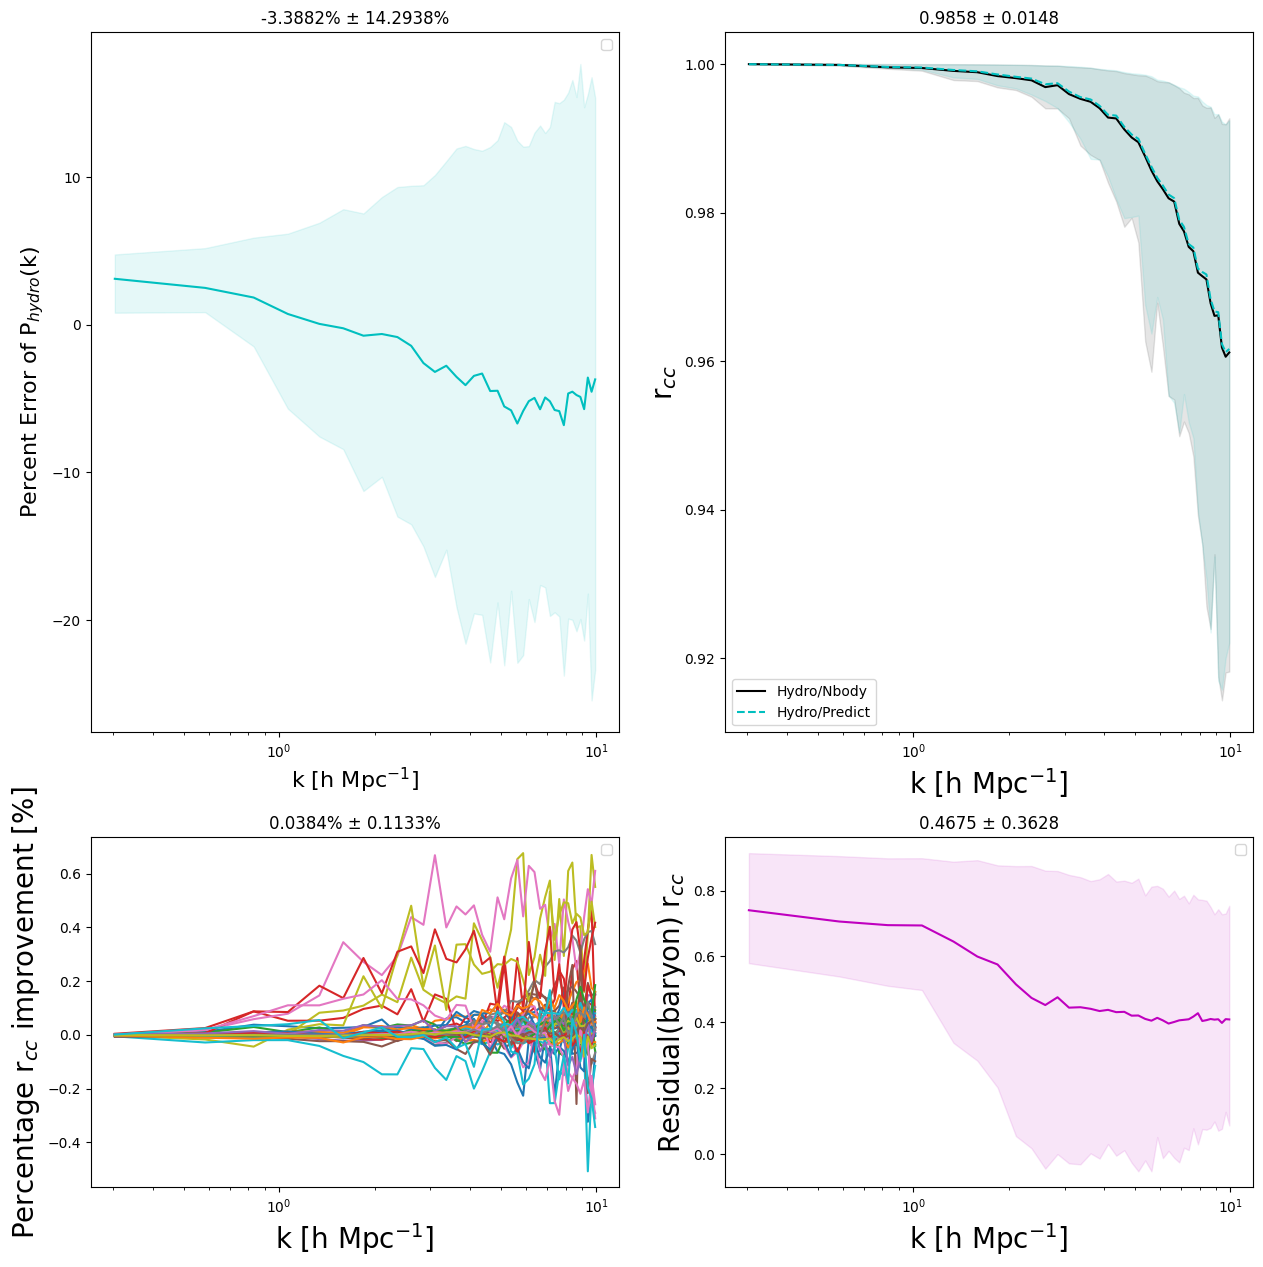

Testing DataLoader 0: 100%|██████████| 6/6 [00:13<00:00,  0.44it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       fourier_loss        │   1.169552888313774e-05   │
│         test_loss         │            0.0            │
│     weighted_l1_loss      │    0.16303123533725739    │
└───────────────────────────┴───────────────────────────┘

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : BigGANUNet2DModel_batch4_vali_rcc_lr_tuning_warmup_fourier_feature_6_7_epoch20_moving_highk_log_Fourier_L1_weight_1e5_10_Smooth_Butterworth_lr_3e4_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                   : https://www.comet.com/klinjin/nbody-hydro/1ea59249057b460098c94cd3723df212
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     fourier_loss     : 1.169552888313774e-05
COMET INFO:     test_loss [2]    : (0.0, 0.15818162262439728)
COMET INFO:     weighted_l1_loss : 0.16303123533725739
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : BigGANUNet2DModel_batch4_vali_rcc_lr_tuni

In [12]:
#model = None: directly load from ckpt
test_loss = trainer.test(cnn, dm_25_thick, ckpt_path = best_path)

In [ ]:
comet_logger.experiment.end()

## Conditional CNN + Fourier Loss + TF: m_cdm -> m_tot-m_cdm_tf (3D->2D: 25 thickness)

In [20]:
dm_TF = get_astro_data_2D_from_3D(
        dataset,
        25,
        num_workers=num_workers,
        resize=cropsize,
        batch_size=batch_size)

In [6]:
print(len(dm_TF.train_data), len(dm_TF.valid_data),len(dm_TF.test_data)) #sum to 3000

2100 600 300


20 tensor(39.4055, grad_fn=<AddBackward0>)


/tmp/ipykernel_652955/2075676437.py:3: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(cnn(cdm_map,params)[0,0,:,:].detach().numpy()))


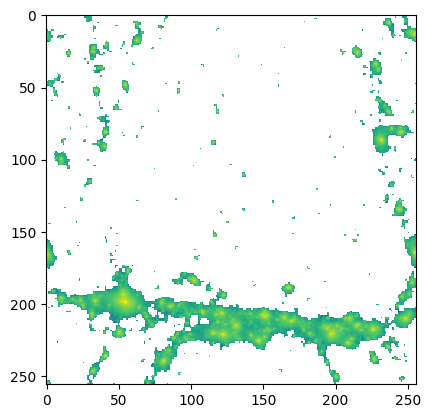

In [29]:
cdm_map,params,true_map = next(iter(dm_TF.train_dataloader()))
print(cnn.current_epoch, cnn.fourier_loss(cnn(cdm_map,params),true_map))
plt.imshow(np.log(cnn(cdm_map,params)[0,0,:,:].detach().numpy()))

In [9]:
trainer.fit(model=cnn, datamodule=dm_TF)

You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/nbody-hydro/750d55d8e44a4cc3a826d9199c7e248a

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | BigGANUNet2DModel | 27.3 M | train
-------------------------------------------

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]
Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing powe

Epoch 0, global step 525: 'val_rcc' reached 0.92602 (best 0.92602), saving model to '/pscratch/sd/l/lindajin/LOGS/Nbody_Hydro/750d55d8e44a4cc3a826d9199c7e248a/checkpoints/best_model-epoch=0-step=525.ckpt' as top 1


Epoch 1: 100%|██████████| 525/525 [01:00<00:00,  8.68it/s, v_num=248a, fourier_loss_step=0.997, weighted_l1_loss_step=0.229, fourier_loss=2.960, weighted_l1_loss=0.385, val_loss=2.960, val_rcc=0.926, fourier_loss_epoch=6.140, weighted_l1_loss_epoch=0.612]
idation: |          | 0/? [00:00<?, ?it/s]
idation DataLoader 0:   0%|          | 0/150 [00:00<?, ?it/s]
Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds


/global/homes/l/lindajin/utils.py:224: RuntimeWarning: invalid value encountered in log
  im = ax.flat[2].imshow(np.log(sample0+1), cmap='copper', vmin=-2, vmax=5)


...

Epoch 18, global step 9975: 'val_rcc' was not in top 1


Epoch 19: 100%|██████████| 525/525 [01:00<00:00,  8.66it/s, v_num=248a, fourier_loss_step=0.888, weighted_l1_loss_step=0.181, fourier_loss=1.130, weighted_l1_loss=0.185, val_loss=1.130, val_rcc=0.929, fourier_loss_epoch=1.170, weighted_l1_loss_epoch=0.185]
idation: |          | 0/? [00:00<?, ?it/s]
idation DataLoader 0:   0%|          | 0/150 [00:00<?, ?it/s]
Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of

Epoch 19, global step 10500: 'val_rcc' was not in top 1
`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 525/525 [01:06<00:00,  7.90it/s, v_num=248a, fourier_loss_step=0.888, weighted_l1_loss_step=0.181, fourier_loss=1.060, weighted_l1_loss=0.185, val_loss=1.060, val_rcc=0.929, fourier_loss_epoch=1.160, weighted_l1_loss_epoch=0.185]


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : BigGANUNet2DModel_TF_EFT_RandN_1e2a0_more_resnet_attn_batch4_vali_rcc_lr_tuning_warmup_fourier_feature_epoch20_log_moving_fourier_filters_longer_6_20_lr_3e4_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                   : https://www.comet.com/klinjin/nbody-hydro/750d55d8e44a4cc3a826d9199c7e248a
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     fourier_loss [20]           : (1.0590152740478516, 2.9587512016296387)
COMET INFO:     fourier_loss_epoch [20]     : (1.1644461154937744, 6.141129016876221)
COMET INFO:     fourier_loss_step [210]     : (0.402207612991333, 9.908697128295898)
COMET INFO:     lr-AdamW [20]               : (8.31705081

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/nbody-hydro/f93c96ae4488434c9e136a6219b11a25

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/Nbody_Hydro/750d55d8e44a4cc3a826d9199c7e248a/checkpoints/best_model-epoch=15-step=8400.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'BigGANUNet2DModel(
  (fourier_features): FourierFeatures()
  (act): SiLU()
  (all_modules): ModuleList(
    (0): Conv2d(18, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1-3): 3 x ResnetBlockBigGANpp(
      (GroupNorm_0): GroupNorm(8, 32, eps=1e-06, affine=True)
      (Conv

Testing DataLoader 0:   0%|          | 0/3 [00:00<?, ?it/s]
Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectr

/global/homes/l/lindajin/utils.py:416: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.flat[2].legend()
/global/homes/l/lindajin/utils.py:427: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.flat[3].legend()



Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time t

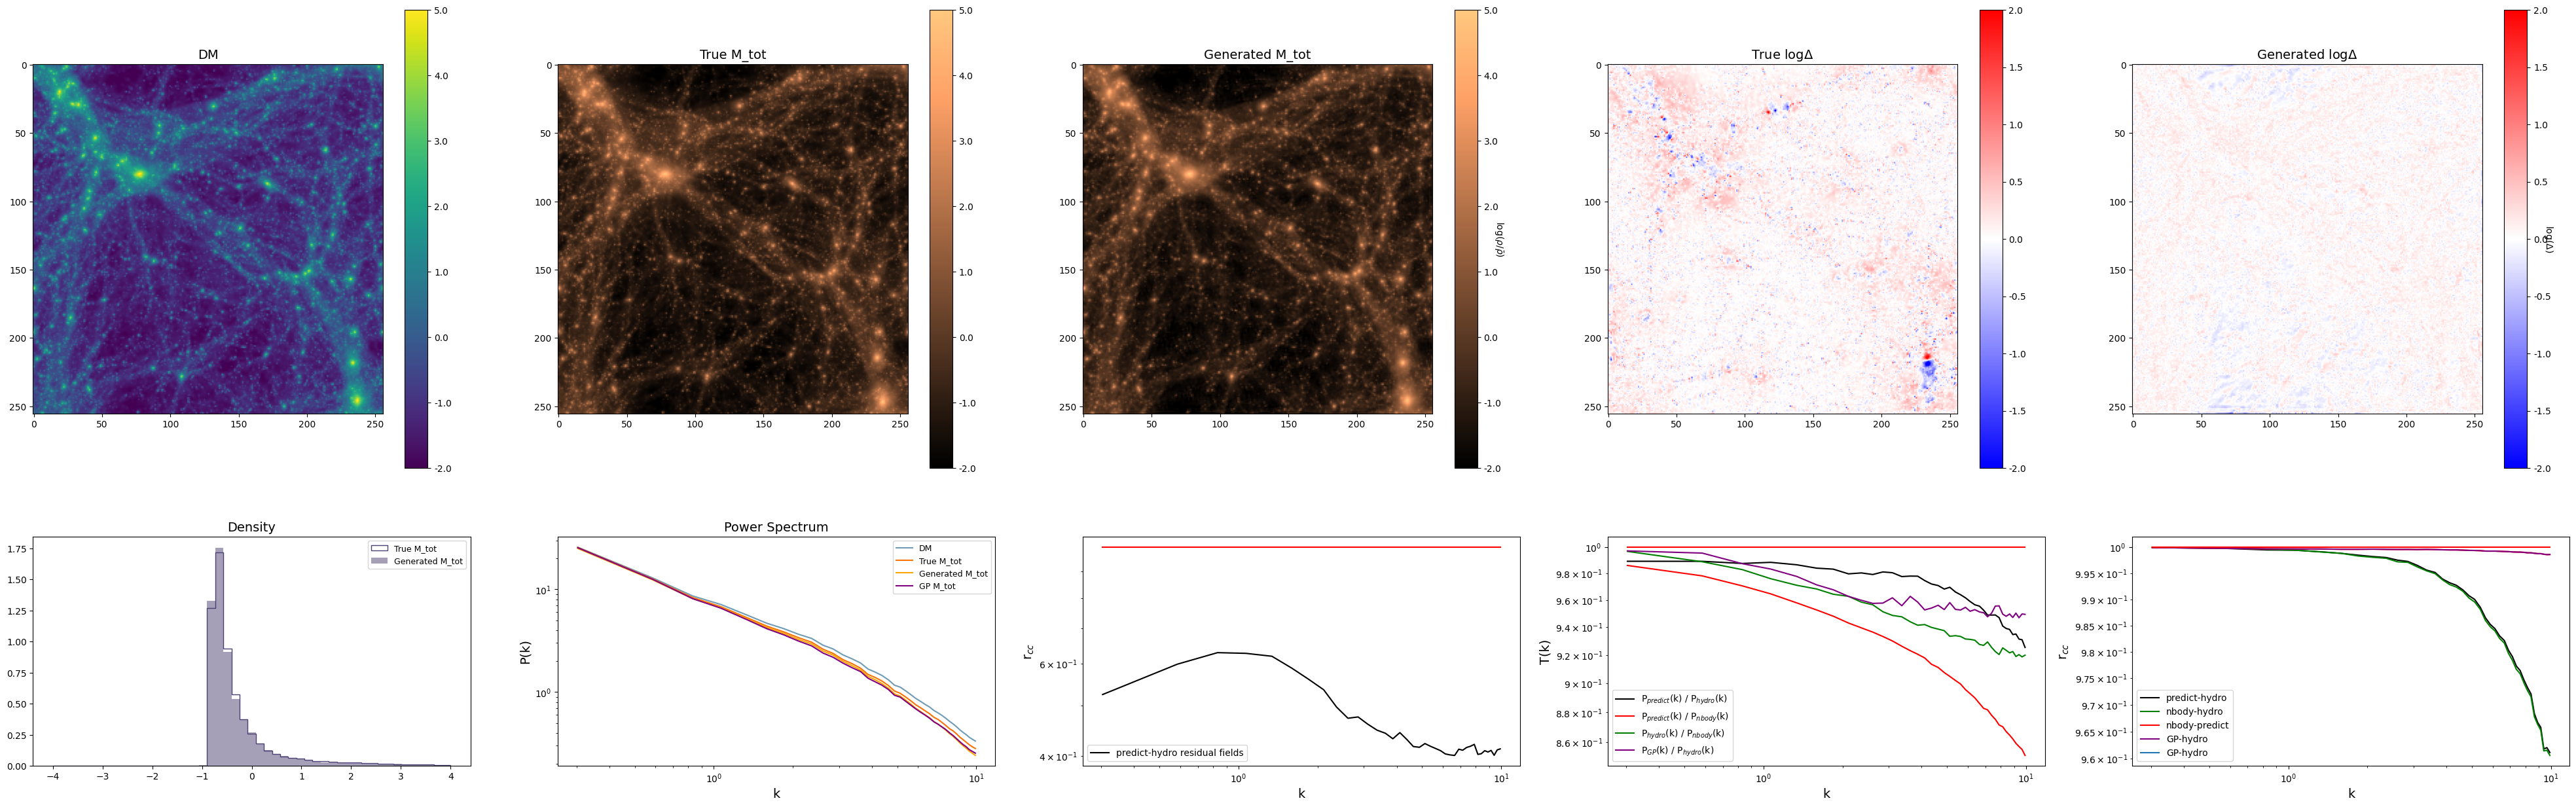

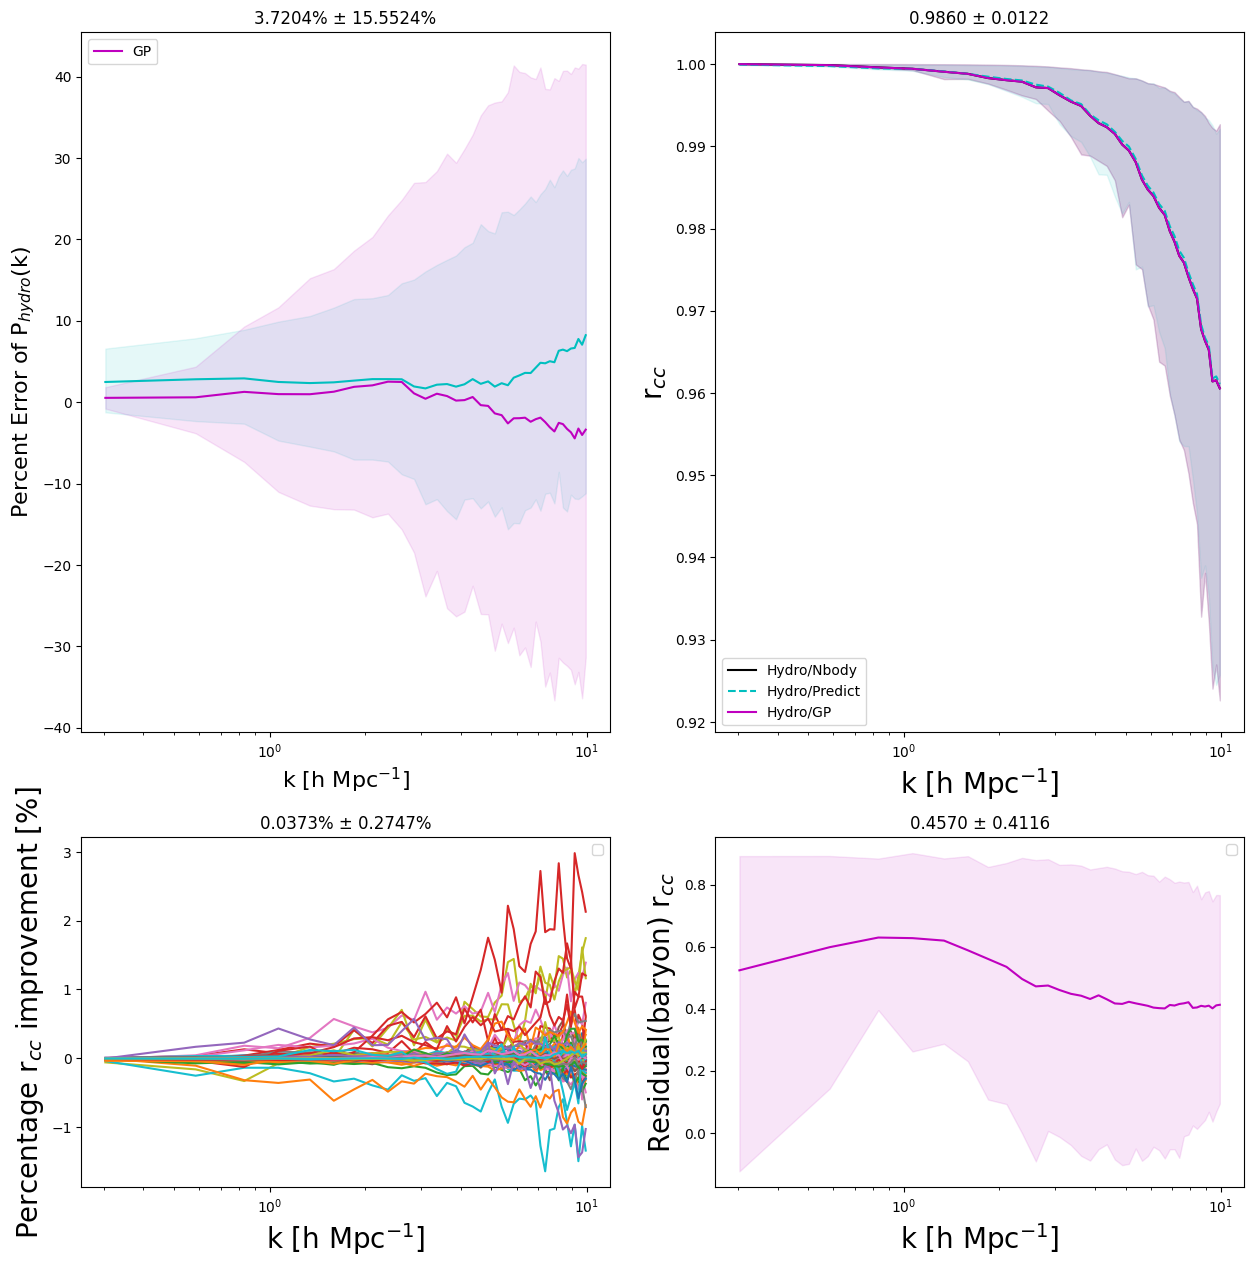

Testing DataLoader 0: 100%|██████████| 3/3 [00:23<00:00,  0.13it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       fourier_loss        │     1.158012866973877     │
│         test_loss         │            0.0            │
│         test_rcc          │    0.9859885573387146     │
│     weighted_l1_loss      │    0.1797637641429901     │
└───────────────────────────┴───────────────────────────┘

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : BigGANUNet2DModel_TF_EFT_RandN_1e2a0_more_resnet_attn_batch4_vali_rcc_lr_tuning_warmup_fourier_feature_epoch20_log_moving_fourier_filters_longer_6_20_lr_3e4_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                   : https://www.comet.com/klinjin/nbody-hydro/f93c96ae4488434c9e136a6219b11a25
COMET INFO:   Metrics:
COMET INFO:     fourier_loss     : 1.158012866973877
COMET INFO:     test_l1_loss     : 0.17812497913837433
COMET INFO:     test_loss        : 0.0
COMET INFO:     test_rcc         : 0.9859885573387146
COMET INFO:     weighted_l1_loss : 0.1797637641429901
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET IN

In [23]:
best_path = val_checkpoint.best_model_path 
print(best_path)
test_loss = trainer.test(cnn, dm_TF, ckpt_path = best_path)

In [24]:
comet_logger.experiment.end()

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/nbody-hydro/f93c96ae4488434c9e136a6219b11a25

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : BigGANUNet2DModel_TF_EFT_RandN_1e2a0_more_resnet_attn_batch4_vali_rcc_lr_tuning_warmup_fourier_feature_epoch20_log_moving_fourier_filters_longer_6_20_lr_3e4_adamw_1e2_25_thickness_Nbody
COMET INFO:     url                   : https://www.comet.com/kli

## test if CNN_apply is correct --> ✅

In [ ]:
comet_logger.experiment.end()

In [70]:
test_predictions_ONLY_fourier_loss = trainer.predict(model=cnn, dataloaders=dm_25_thick.train_dataloader(), ckpt_path = path_UNet_Film_10_epochs_ONLY_fourier_loss_3_10_zeros_elsewhere_25_thick)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/baryonize-dm/96071eeeabd64a0da32d6e71b78e41a9

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/baryonize_DM/5ef90d60aaca4012837cd4275273e171/checkpoints/latest-epoch=9-step=1750.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=circular)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tru

Predicting DataLoader 0: 100%|██████████| 175/175 [00:05<00:00, 29.50it/s]


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Unet_new_Film_Fourier_L1_weight_1e-4_2_20_high_pass_lr_5e-3_25_thickness
COMET INFO:     url                   : https://www.comet.com/klinjin/baryonize-dm/96071eeeabd64a0da32d6e71b78e41a9
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : Unet_new_Film_Fourier_L1_weight_1e-4_2_20_high_pass_lr_5e-3_25_thickness
COMET INFO:   Parameters:
COMET INFO:     dataset          : Astrid
COMET INFO:     image_shape      : (1, 256, 256)
COMET INFO:     learning_rate    : 0.005
COMET INFO:     model            : UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel

In [72]:
test_predictions_ONLY_fourier_loss = np.array(test_predictions_ONLY_fourier_loss).reshape([2100,256,256]) #path_UNet_Film_50_epochs_fourier_loss_2_10

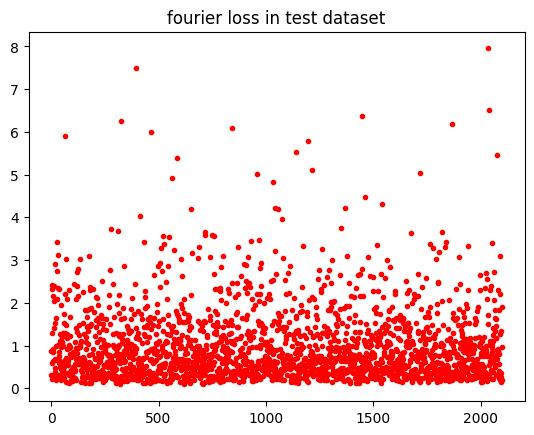

In [86]:
test_target = []
for t in dm_25_thick.train_data:
    test_target.append(t[2])
    
test_predictions_ONLY_fourier_loss_ = Tensor(np.array(test_predictions_ONLY_fourier_loss)).unsqueeze(1)
test_predictions_ = Tensor(test_predictions).unsqueeze(1)

plt.figure()
for i in np.arange(len(test_predictions)):                
    loss = cnn.fourier_loss(test_predictions_ONLY_fourier_loss_[i].unsqueeze(0), test_target[i])
    plt.plot(i, loss, '.', c='r')
plt.title('fourier loss in test dataset')
plt.show()

In [84]:
print(len(test_target))

2100


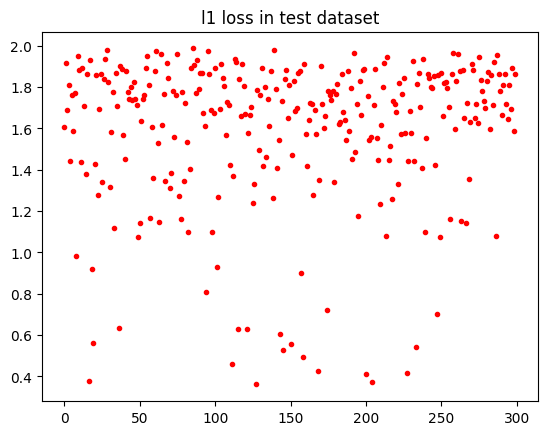

In [44]:
plt.figure()
for i in np.arange(len(test_predictions)):                
    loss =  l1_loss(test_predictions_[i].unsqueeze(0), test_targets_[i])
    plt.plot(i, loss, '.', c='r')
plt.title('l1 loss in test dataset')
plt.show()

In [75]:
test_predictions = trainer.predict(model=cnn, dataloaders=dm_25_thick.train_dataloader(), ckpt_path = path_UNet_Film_10_epochs_ONLY_l1_loss_25_thick)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/klinjin/baryonize-dm/96071eeeabd64a0da32d6e71b78e41a9

Restoring states from the checkpoint path at /pscratch/sd/l/lindajin/LOGS/baryonize_DM/62ce892d8ce84414ad1d864f0b3c09a3/checkpoints/latest-epoch=9-step=1750.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=circular)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tru

Predicting DataLoader 0: 100%|██████████| 175/175 [00:05<00:00, 29.36it/s]


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml ExistingExperiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Unet_new_Film_Fourier_L1_weight_1e-4_2_20_high_pass_lr_5e-3_25_thickness
COMET INFO:     url                   : https://www.comet.com/klinjin/baryonize-dm/96071eeeabd64a0da32d6e71b78e41a9
COMET INFO:   Others:
COMET INFO:     Created from : pytorch-lightning
COMET INFO:     Name         : Unet_new_Film_Fourier_L1_weight_1e-4_2_20_high_pass_lr_5e-3_25_thickness
COMET INFO:   Parameters:
COMET INFO:     dataset          : Astrid
COMET INFO:     image_shape      : (1, 256, 256)
COMET INFO:     learning_rate    : 0.005
COMET INFO:     model            : UNetFiLM(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel

train on L1 only


/tmp/ipykernel_1997182/3169583532.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_predictions = Tensor(np.array(test_predictions).reshape([2100,1,256,256]))


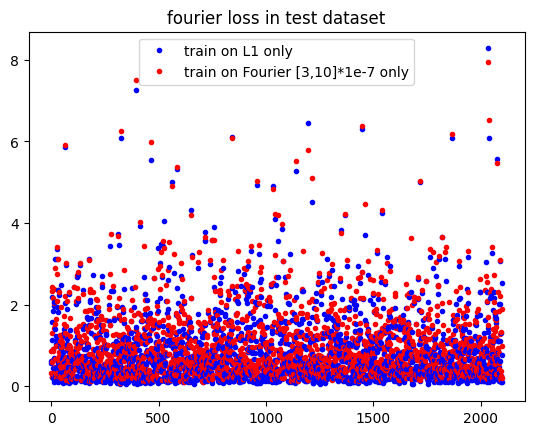

/tmp/ipykernel_1997182/3169583532.py:23: UserWarning: Using a target size (torch.Size([1, 256, 256])) that is different to the input size (torch.Size([1, 1, 256, 256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss =  l1_loss(test_predictions[i].unsqueeze(0), test_target[i])
/tmp/ipykernel_1997182/3169583532.py:28: UserWarning: Using a target size (torch.Size([1, 256, 256])) that is different to the input size (torch.Size([1, 1, 256, 256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = l1_loss(test_predictions_ONLY_fourier_loss_[i].unsqueeze(0), test_target[i])


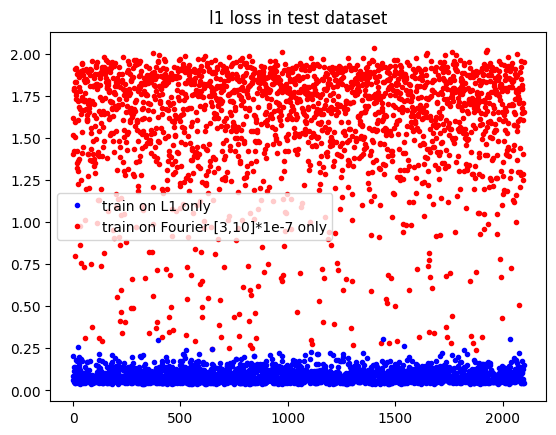

In [87]:
print('train on L1 only')

test_predictions = Tensor(np.array(test_predictions).reshape([2100,1,256,256]))

plt.figure()
for i in np.arange(len(test_predictions)):                
    loss = cnn.fourier_loss(test_predictions[i].unsqueeze(0), test_target[i])
    if i == 0:
        plt.plot(i, loss, '.', c='b', label = 'train on L1 only')
    else:
        plt.plot(i, loss, '.', c='b')
    loss = cnn.fourier_loss(test_predictions_ONLY_fourier_loss_[i].unsqueeze(0), test_target[i])
    if i == 0:
        plt.plot(i, loss, '.', c='r', label = 'train on Fourier [3,10]*1e-7 only')
    else:
        plt.plot(i, loss, '.', c='r')
plt.title('fourier loss in test dataset')
plt.legend()
plt.show()

plt.figure()
for i in np.arange(len(test_predictions)):                
    loss =  l1_loss(test_predictions[i].unsqueeze(0), test_target[i])
    if i == 0:
        plt.plot(i, loss, '.', c='b', label = 'train on L1 only')
    else:
        plt.plot(i, loss, '.', c='b')
    loss = l1_loss(test_predictions_ONLY_fourier_loss_[i].unsqueeze(0), test_target[i])
    if i == 0:
        plt.plot(i, loss, '.', c='r', label = 'train on Fourier [3,10]*1e-7 only')
    else:
        plt.plot(i, loss, '.', c='r')
plt.title('l1 loss in test dataset')
plt.legend()
plt.show()